In [2]:
import sys
sys.path.append('../')

import numpy as np
import scipy.sparse as ssp
import matplotlib.pyplot as plt
import qutip as qt
import scqubits as scq
from matplotlib.colors import LogNorm
from tqdm import tqdm
from qutip.qip.operations import rz, cz_gate
import cmath
from sympy import symbols
import utils_2Q_gate_zp as ut
import scipy as sp
from joblib import Parallel, delayed
import pandas as pd
import itertools
from qutip.qip.operations import rz, cz_gate, cnot, rx, hadamard_transform

In [3]:
f = pd.read_csv('data/data_cnot_45_2A.txt').to_numpy()


In [3]:
fidelity_14_2A_combine = [0.5184182997800467, 0.6759875129318533, 0.795766121576647,
0.86386278775011, 0.9416538406488264, 0.9381183577963004, 0.9570164489358659,
0.9553915401325936, 0.9533334277514843, 0.9757216392731017, 0.9840901447663579,
0.9927355824906225, 0.9955156136304992,0.996297267515029, 0.9991820809881627,
0.9995669444695412,0.9999277641159935, 0.9999230341148969, 0.9999819480872094,
0.9999889622325279,0.999995930274163, 0.9999995952044058,
]
drive_param_14_2A_combine = [
[0.13655477501019325, 0.10794615494328463, 19.99999999412964, -0.1373728419868848, -0.12647877284253578],
[0.13241611373174095, 0.11250934322800019, 32.857142851461, -0.17780126875378566, -0.16663004414450908],
[0.1346592242690052, 0.12763884958760502, 45.71428570811034, -0.2405578162252669, -0.22720278135901742],
[0.13642510901400648, 0.14177261808958422, 58.5714285652226, -0.29992146912676343, -0.2844545017345545],
[0.20968894214945819, 0.11375180331797835, 84.28571428275639, -0.2596106198879004, -0.27852722518057355],
[0.11526320444441393, 0.12481643898279215, 97.14285713751849, -0.22203452653045946, -0.20924903512889548],
[0.11880611014675484, 0.13399141225935418, 109.99999999436317, -0.258890225439262, -0.24473645588570242],
[0.20948133295077548, 0.08590173432174125, 122.85714285189243, -0.22463838412830428, -0.2845710761610976],
[0.0757304742236375, 0.04442869405857458, 135.7142857056725, -0.037887577634313885, -0.044916255039324185],
[0.20940123819257545, 0.07896208845110898, 148.5714285624567, -0.2394379869836075, -0.28492570540717854],
[0.20000268616944536, 0.07332735845639228, 161.42857142035075, -0.2298248001980925, -0.26676037126894997],
[0.09198336544909672, 0.0981689360664377, 174.2857142800867, -0.02431327060564875, -0.017670618989625908],
[0.08875362517793295, 0.03745505209768381, 199.99999999606837, -0.04283226869094012, -0.05232422288208745],
[0.06603415954649548, 0.032313257221391674, 215.39818844027002, -0.028110942948351314, -0.03363993397033299],
[0.06561456119771665, 0.03256070030188406, 255.8568219747646, -0.03309632759894371, -0.03658041169233178],
[0.07830073076579484, 0.026863026615025726, 279.9999668380671, -0.031160109465253563, -0.03927095234589164],
[0.07601957910756506, 0.02504258843180761, 309.9999668866966, -0.030272682505848345, -0.03755469639929651],
[0.09150631840114574, 0.022780016816926225, 339.9999145642021, -0.029821737356828013, -0.04530933349733816],
[0.0818997141250141, 0.020776995821780754, 369.9999856598085, -0.026755200445700643, -0.03822141709100123],
[0.06517893233226774, 0.017060124583084493, 399.9999906572392, -0.01611114211193787, -0.025302012374410956],
[0.07368360422310369, 0.01681222219061629, 420.13378612121545, -0.0164934651853555, -0.029706520480420585],
[0.07953654959206298, 0.021779220858655912, 452.90000022645984, -0.009208037275464275, -0.025201661422210253],
]
Infidelity_14_2A_combine = 1-np.array(fidelity_14_2A_combine)

In [4]:
tg_vec = np.linspace(77.85, 116.43, num=4)
tg_bounds = []
for i in range(len(tg_vec)):
    tg_bounds.append((tg_vec[i]-0.00001, tg_vec[i]))
print(tg_bounds)
print('\n', tg_vec)

[(77.84998999999999, 77.85), (90.70998999999999, 90.71), (103.56999, 103.57000000000001), (116.42999, 116.43)]

 [ 77.85  90.71 103.57 116.43]


In [6]:
fidelity_45_2A_tg20 =  [-0.3275708120411501, -0.40677984768893705, -0.6553425041054183,
-0.8684089592250834, -1.1504818537190125,-1.5103278101077502,  -1.72623,
-2.1169463782708764, -2.2837538953371133, -2.10131,-1.2426815176853503,
-1.4505178100489904, -3.3206190233636392, -1.6009618468413203, -1.6675815915152072]
drive_param_45_2A_tg20 =  [[0.2937827074094986, 0.20716334517023793, 19.999999995554614, -0.29985346338788776, -0.2810489670564227],
[0.10241089479179045, 0.06657146402863781, 32.85714285436836, -0.2462594563490309, -0.24266678967744326],
[0.09287652451928688, 0.061844282528780575, 45.71428571274179, -0.2451981804328725, -0.24228288097087214],
[0.0819633839079435, 0.05831298445446166, 58.57142856579773, -0.24299948279462152, -0.23999687056851765],
[0.08771058899123453, 0.06686043048119122, 71.42857142055747, -0.26245648784041775, -0.25872289932942755],
[0.0801041189074392, 0.06295752074291067, 84.28571428554989, -0.2579714639254799, -0.2543572915116533],
[0.13983228791548039, 0.12798854082621794, 97.14285713489781, -0.19243161939360756, -0.1835945911269467],
[0.07457781167872617, 0.06346544364160163, 109.99999999900716, -0.2634629366012341, -0.25926915494277636],
[0.07167743528810211, 0.06109928816714061, 122.85714285453055, -0.26147399950814865, -0.25756381463302325],
[0.12083369502514277, 0.10805662480462044, 135.714285707008, -0.15641067727071517, -0.1410672734660711],
[0.11378070699556589, 0.10621660369823538, 148.57142856532306, -0.14852863961709353, -0.13454275436860283],
[0.11998312616302251, 0.10943279347805836, 161.42857142718734, -0.16261487994573556, -0.14848056696839515],
[0.13659946069124618, 0.034396174967731535, 174.28571427594133, -0.265980086444273, -0.2791332546137629],
[0.15895473139364275, 0.09246096135475615, 187.14285713828065, -0.1522811301538221, -0.15942596214176985],
[0.17740230896165765, 0.08073493055731411, 199.99999999884747, -0.1440099599643176, -0.15624423251775954]]
Infidelity_45_2A_tg20 = [10**(fidelity_45_2A_tg20[i]) for i in range(len(fidelity_45_2A_tg20))]

In [7]:
fidelity_45_2A_tg20_better =  [-0.3275708120411501, -0.40677984768893705, -0.6553425041054183,
-0.8684089592250834, -1.1504818537190125,-1.5103278101077502,  -1.72623,
-2.1169463782708764, -2.2837538953371133, -2.10131, -2.22274,
-2.5048181850820264, -3.3206190233636392, -3.19015, -2.82059]
drive_param_45_2A_tg20_better =  [[0.2937827074094986, 0.20716334517023793, 19.999999995554614, -0.29985346338788776, -0.2810489670564227],
[0.10241089479179045, 0.06657146402863781, 32.85714285436836, -0.2462594563490309, -0.24266678967744326],
[0.09287652451928688, 0.061844282528780575, 45.71428571274179, -0.2451981804328725, -0.24228288097087214],
[0.0819633839079435, 0.05831298445446166, 58.57142856579773, -0.24299948279462152, -0.23999687056851765],
[0.08771058899123453, 0.06686043048119122, 71.42857142055747, -0.26245648784041775, -0.25872289932942755],
[0.0801041189074392, 0.06295752074291067, 84.28571428554989, -0.2579714639254799, -0.2543572915116533],
[0.13983228791548039, 0.12798854082621794, 97.14285713489781, -0.19243161939360756, -0.1835945911269467],
[0.07457781167872617, 0.06346544364160163, 109.99999999900716, -0.2634629366012341, -0.25926915494277636],
[0.07167743528810211, 0.06109928816714061, 122.85714285453055, -0.26147399950814865, -0.25756381463302325],
[0.12083369502514277, 0.10805662480462044, 135.714285707008, -0.15641067727071517, -0.1410672734660711],
[ 1.39649438e-01,  3.75889614e-02,  1.48571428e+02, -2.64865308e-01, -2.80016464e-01],
[0.1928249640002235, 0.04240198183227892, 161.4285720028971, -0.2965212556210125, -0.3370487537549116],
[0.13659946069124618, 0.034396174967731535, 174.28571427594133, -0.265980086444273, -0.2791332546137629],
[ 2.29982096e-01,  4.33528437e-02,  1.87142857e+02, -3.23876876e-01, -3.87682399e-01],
[ 2.71343525e-01,  4.76659134e-02,  2.00000000e+02, -3.51064026e-01, -4.52948526e-01]]
Infidelity_45_2A_tg20_better = [10**(fidelity_45_2A_tg20_better[i]) for i in range(len(fidelity_45_2A_tg20_better))]

In [8]:

fidelity_45_2A_tg26 =  [-0.38507756476129795, -0.525405502288454, -0.7747122825303822,
-0.4997869897362499, -1.329483437983519, -1.6680010156505054, -1.9311021800638017,
-2.2504116414129642, -2.2600203310051925, -1.2124665250852003, -2.8833872708986252,
-1.446912290911912, -1.466037331065023, -1.5686040863902107]
drive_param_45_2A_tg26 =  [[0.19986763342174885, 0.16542912549771863, 26.42999999972073, -0.29995109980699497, -0.2856201177893835],
[0.09845211687279845, 0.0635170012204257, 39.28714285020199, -0.2456353871466505, -0.24261665762800577],
[0.08500734818444178, 0.05856076763302001, 52.14428570949333, -0.24148295400186431, -0.23880702281796262],
[0.14004272311772292, 0.10974210537517687, 65.00142856963603, -0.14402238638017772, -0.13718055296432824],
[0.08268960866217097, 0.064863772595279, 77.85857142091432, -0.25980482928154175, -0.2558455812951337],
[0.07719412517552891, 0.06146966245411766, 90.71571427741362, -0.25644132615156356, -0.25295439881444515],
[0.07605206228322481, 0.06394327988621684, 103.57285713794444, -0.26325391779668506, -0.25904630888794034],
[0.07307225018818418, 0.062044007381991596, 116.42999999438533, -0.2621150841012345, -0.2581497140779373],
[0.13937567737020468, 0.04124523368094756, 129.28714285080468, -0.26084290275881383, -0.2794343547842829],
[0.12297691352447393, 0.11022939634875134, 142.14428571116434, -0.16439437190920544, -0.1488185541293143],
[0.14034294764244026, 0.03719911103182841, 155.00142856313832, -0.26608312732559963, -0.28162832517153685],
[0.11086199385417886, 0.10616590127481114, 167.85857141948196, -0.14857150436750974, -0.13567069753929187],
[0.15263584481978948, 0.09307925955463721, 180.71571427963235, -0.14592111691686005, -0.15364289907498765],
[0.14578771721907205, 0.0839166360668595, 193.57285714152405, -0.12486815164695064, -0.1323318076241999]]
Infidelity_45_2A_tg26 = [10**(fidelity_45_2A_tg26[i]) for i in range(len(fidelity_45_2A_tg26))]

fidelity_45_2A_tg26_better =  [-0.38507756476129795, -0.525405502288454, -0.7747122825303822,
-0.4997869897362499, -1.329483437983519, -1.6680010156505054, -1.9311021800638017,
-2.2504116414129642, -2.2600203310051925, -2.244537941118768, -2.8833872708986252,
-1.446912290911912, -1.466037331065023, -1.5686040863902107]
drive_param_45_2A_tg26_better =  [[0.19986763342174885, 0.16542912549771863, 26.42999999972073, -0.29995109980699497, -0.2856201177893835],
[0.09845211687279845, 0.0635170012204257, 39.28714285020199, -0.2456353871466505, -0.24261665762800577],
[0.08500734818444178, 0.05856076763302001, 52.14428570949333, -0.24148295400186431, -0.23880702281796262],
[0.14004272311772292, 0.10974210537517687, 65.00142856963603, -0.14402238638017772, -0.13718055296432824],
[0.08268960866217097, 0.064863772595279, 77.85857142091432, -0.25980482928154175, -0.2558455812951337],
[0.07719412517552891, 0.06146966245411766, 90.71571427741362, -0.25644132615156356, -0.25295439881444515],
[0.07605206228322481, 0.06394327988621684, 103.57285713794444, -0.26325391779668506, -0.25904630888794034],
[0.07307225018818418, 0.062044007381991596, 116.42999999438533, -0.2621150841012345, -0.2581497140779373],
[0.13937567737020468, 0.04124523368094756, 129.28714285080468, -0.26084290275881383, -0.2794343547842829],

[0.0689818682904551, 0.060899876900305884, 142.13999999293074, -0.2633990274586357, -0.25940703714064756],
[0.14034294764244026, 0.03719911103182841, 155.00142856313832, -0.26608312732559963, -0.28162832517153685],

[0.11086199385417886, 0.10616590127481114, 167.85857141948196, -0.14857150436750974, -0.13567069753929187],
[0.15263584481978948, 0.09307925955463721, 180.71571427963235, -0.14592111691686005, -0.15364289907498765],
[0.14578771721907205, 0.0839166360668595, 193.57285714152405, -0.12486815164695064, -0.1323318076241999]]
Infidelity_45_2A_tg26_better = [10**(fidelity_45_2A_tg26_better[i]) for i in range(len(fidelity_45_2A_tg26_better))]

In [9]:
fidelity_45_2A = fidelity_45_2A_tg20 + fidelity_45_2A_tg26
drive_param_45_2A = drive_param_45_2A_tg20 + drive_param_45_2A_tg26
merged_45_2A = [drive_param + [fidelity] for fidelity, drive_param in zip(fidelity_45_2A, drive_param_45_2A)]
merged_45_2A = np.array(sorted(merged_45_2A, key=lambda x: x[2]))
Infidelity_45_2A = [10**(merged_45_2A[i,5]) for i in range(merged_45_2A.shape[0])]

fidelity_45_2A_better = fidelity_45_2A_tg20_better + fidelity_45_2A_tg26_better
drive_param_45_2A_better = drive_param_45_2A_tg20_better + drive_param_45_2A_tg26_better
merged_45_2A_better = [drive_param + [fidelity] for fidelity, drive_param in zip(fidelity_45_2A_better, drive_param_45_2A_better)]
merged_45_2A_better = np.array(sorted(merged_45_2A_better, key=lambda x: x[2]))
Infidelity_45_2A_better = [10**(merged_45_2A_better[i,5]) for i in range(merged_45_2A_better.shape[0])]

In [11]:
merged_45_2A_best = np.array([
[ 2.93782707e-01,  2.07163345e-01,  2.00000000e+01,-2.99853463e-01, -2.81048967e-01, -3.27570812e-01],
[ 1.99867633e-01,  1.65429125e-01,  2.64300000e+01,-2.99951100e-01, -2.85620118e-01, -3.85077565e-01],
[ 1.02410895e-01,  6.65714640e-02,  3.28571429e+01,-2.46259456e-01, -2.42666790e-01, -4.06779848e-01],
[ 9.84521169e-02,  6.35170012e-02,  3.92871429e+01,-2.45635387e-01, -2.42616658e-01, -5.25405502e-01],
[ 9.28765245e-02,  6.18442825e-02,  4.57142857e+01,-2.45198180e-01, -2.42282881e-01, -6.55342504e-01],
[ 8.50073482e-02,  5.85607676e-02,  5.21442857e+01,-2.41482954e-01, -2.38807023e-01, -7.74712283e-01],
[ 8.19633839e-02,  5.83129845e-02,  5.85714286e+01,-2.42999483e-01, -2.39996871e-01, -8.68408959e-01],
[ 0.09085433,  0.06723939, 65.00142837, -0.26168943, -0.2577288, -0.9844214061746501 ],
[ 8.77105890e-02,  6.68604305e-02,  7.14285714e+01,-2.62456488e-01, -2.58722899e-01, -1.15048185e+00],
[ 8.26896087e-02,  6.48637726e-02,  7.78585714e+01,-2.59804829e-01, -2.55845581e-01, -1.32948344e+00],
[ 8.01041189e-02,  6.29575207e-02,  8.42857143e+01,-2.57971464e-01, -2.54357292e-01, -1.51032781e+00],
[ 7.71941252e-02,  6.14696625e-02,  9.07157143e+01,-2.56441326e-01, -2.52954399e-01, -1.66800102e+00],
[0.075351643, 0.06135683, 97.14285, -0.25725, -0.25353, -1.79079],

[ 7.60520623e-02,  6.39432799e-02,  1.03572857e+02,-2.63253918e-01, -2.59046309e-01, -1.93110218e+00],
[ 7.45778117e-02,  6.34654436e-02,  1.10000000e+02,-2.63462937e-01, -2.59269155e-01, -2.11694638e+00],
[ 7.30722502e-02,  6.20440074e-02,  1.16430000e+02,-2.62115084e-01, -2.58149714e-01, -2.25041164e+00],
[ 7.16774353e-02,  6.10992882e-02,  1.22857143e+02,-2.61474000e-01, -2.57563815e-01, -2.28375390e+00],
[ 1.39375677e-01,  4.12452337e-02,  1.29287143e+02,-2.60842903e-01, -2.79434355e-01, -2.26002033e+00],
[ 1.36380478e-01,  3.94416719e-02,  1.35714286e+02, -2.59402399e-01, -2.76635053e-01, -2.50436],
[ 1.33690914e-01,  3.79693451e-02 , 1.42140000e+02 ,-2.58306995e-01, -2.74236850e-01, -2.68068],
[ 1.33143163e-01,  3.69228390e-02,  1.48571428e+02, -2.58921599e-01, -2.74046847e-01,  -2.73726],
[ 1.40342948e-01,  3.71991110e-02,  1.55001429e+02, -2.66083127e-01, -2.81628325e-01, -2.88338727e+00],
[ 1.39949303e-01,  3.61571071e-02,  1.61428573e+02, -2.66656925e-01, -2.81472098e-01, -3.11159],
[ 1.39496859e-01,  3.55201590e-02,  1.67858570e+02, -2.67606025e-01, -2.81677946e-01,   -3.21012],
[ 1.36599461e-01,  3.43961750e-02,  1.74285714e+02,-2.65980086e-01, -2.79133255e-01, -3.32061902e+00],
[ 1.85754469e-01,  3.80918860e-02,  1.80715714e+02, -2.95110129e-01, -3.28798105e-01,  -3.15373],
[ 1.86997685e-01,  3.74284980e-02,  1.87142856e+02, -2.98005591e-01, -3.30703646e-01,  -3.24536],
[ 1.32295234e-01,  3.22886233e-02,  1.93572855e+02, -2.65458734e-01, -2.76565235e-01, -3.51013],
[ 2.32894448e-01,  4.20098643e-02,  1.99999999e+02, -3.33118430e-01, -3.92974542e-01,  -3.46532]
])
Infidelity_45_2A_best = [10**(merged_45_2A_best[i,5]) for i in range(merged_45_2A_best.shape[0])]


In [14]:
merged_45_2A_ = np.hstack((
    np.round(merged_45_2A_best[:,2], 2).reshape(29, 1),
    np.round(np.log10(Infidelity_45_2A_best), 5).reshape(29, 1),
    np.round(merged_45_2A_best[:,:2], 8),
    np.round(merged_45_2A_best[:,3:5], 8),
    ))
columns = ['tg',  'fidelity', 'drive_amp_1', 'drive_amp_2', 'detune_1', 'detune_2']
df = pd.DataFrame(merged_45_2A_, columns=columns)
# df.to_csv('data/data_cnot_45_2A.txt', sep=',', index=False, header=True)
# merged_45_2A_

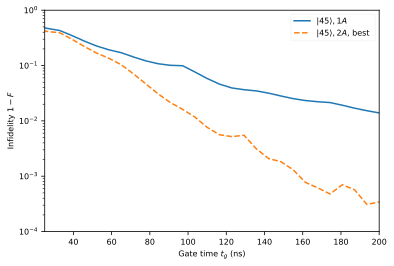

In [15]:
fig, ax = plt.subplots(figsize=(6,4))
# plt.plot(np.array(drive_param_14_1A_combine)[:,1], Infidelity_14_1A_combine, '.-', label=r'$|14\rangle, 1A$ ')
# plt.plot(np.array(drive_param_14_2A_combine)[:,2], Infidelity_14_2A_combine, '.-', label=r'$|14\rangle, 2A$')
# plt.plot(np.array(drive_param_45_2A)[:,2], Infidelity_45_2A, '.-', label=r'$|45\rangle, 2A$ ')
# plt.plot(np.array(drive_param_45_2A_tg20_better)[:,2], Infidelity_45_2A_tg20_better, '.-', label=r'$|45\rangle, 2A, 20$ ')
# plt.plot(np.array(drive_param_45_2A_tg20)[:,2], Infidelity_45_2A_tg20, '.-', label=r'$|45\rangle, 2A, 20$ ')
# plt.plot(np.array(drive_param_45_2A_tg26_better)[:,2], Infidelity_45_2A_tg26_better, '.-', label=r'$|45\rangle, 2A, 26$ ')
# plt.plot(np.array(drive_param_45_2A_tg26)[:,2], Infidelity_45_2A_tg26, '.-', label=r'$|45\rangle, 2A, 26$ ')
# plt.plot(merged_45_2A_better[:,2], Infidelity_45_2A_better, 'x', label=r'$|45\rangle, 2A$, better ')
# plt.plot(merged_45_2A[:,2], Infidelity_45_2A, 'x', label=r'$|45\rangle, 2A,$ ')
plt.plot(merged_45_2A_best[:,2], Infidelity_45_2A_best, '--', label=r'$|45\rangle, 2A$, best ')
plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.ylabel('Infidelity $1-F$')
# plt.grid()
plt.xlim(25,200)
plt.ylim(0.0001,1)
legend = plt.legend(loc='best')
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent
# plt.savefig('cnot_fidelity_2A0_and_1A0.png',dpi=300,bbox_inches='tight')

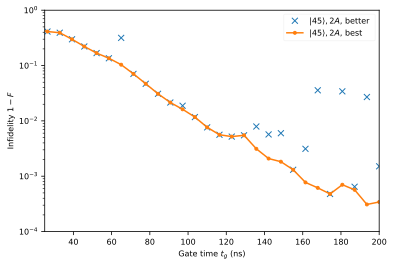

In [16]:
fig, ax = plt.subplots(figsize=(6,4))
plt.plot(merged_45_2A_better[:,2], Infidelity_45_2A_better, 'x', label=r'$|45\rangle, 2A$, better ')
plt.plot(merged_45_2A_best[:,2], Infidelity_45_2A_best, '.-', label=r'$|45\rangle, 2A$, best ')
plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.ylabel('Infidelity $1-F$')
# plt.grid()
plt.xlim(25,200)
plt.ylim(0.0001,1)
legend = plt.legend(loc='best')
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

In [17]:
f_zl_100 =  [0.5296540067391977, 0.5876826687665272, 0.6077477678974776, 0.7013141299016503,
0.7783289516432502, 0.8313722227602192, 0.8638904634443663, 0.8956609738714686,
0.9287008415625324, 0.9526748713236864, 0.9687351117085312, 0.9782196265300008,
0.983565,                     0.9880850156892252, 0.9922350592290693, 0.9943046504527141,
0.9947485030250721, 0.9944706651902127, 0.9968600467195703, 0.9979117038750444,
0.9981713812716972, 0.9986839761340013, 0.9992214777865863, 0.9993814707612682,
0.9995235869475673, 0.9993063135764281, 0.9994393576374812, 0.9996958134397517, 0.9996623535368965]
f_ideal_100 =  [0.5587562631512581, 0.6318627675532253, 0.6589899664528207, 0.7422879186820028,
0.8104728917865061, 0.8582359792064442, 0.8868761061390353, 0.9109531064894231,
0.9396549497181669, 0.960561236349046, 0.974188499834224, 0.9822288244385085,
0.986640,                   0.9899982526943301, 0.993349028959624, 0.9950730985329171,
0.9954227287605312, 0.9953235814165907, 0.997413531714485, 0.9983219830479637,
0.9985210177975304, 0.9989044429779629, 0.9993548585724985, 0.9994763451888297,
0.99961734372034, 0.9994145093666382, 0.9995202070049933, 0.9997460221504483, 0.9997271998515569]
f_noise_100 =  [0.558728445345266, 0.6318150252560499, 0.6589171915863286, 0.7421880191071069,
0.8103447307269708, 0.8580789327815619, 0.8866916719554843, 0.9107458915031895,
0.9394203444777339, 0.9602991610606267, 0.9739004412998457, 0.9819158377901281,
0.986302,                  0.9896367163281283, 0.9929638760972516, 0.9946645597958217,
0.9949912538133727, 0.9948817971263877, 0.996945004276148, 0.9978270383460884,
0.9979997692082776, 0.9983586287797419, 0.9987834691799833, 0.9988792773875584,
0.9989943781527142, 0.9987947335710139, 0.9988758019085366, 0.9990456722394736, 0.9990618563458462]
f_noise_1600 =  [0.5587542420679731, 0.6318568529925936, 0.658979119942439, 0.7422745260938306,
0.8104574340874311, 0.8582180231907646, 0.8868554011784464, 0.9109324017248156,
0.9396334916934336, 0.9605389045631195, 0.9741655700619651, 0.9822049743906078,
0.986302, 0.9899728514032894, 0.9933228338445745, 0.9950457126358321,
0.9953939659773858, 0.9952942664662465, 0.9973827385584398, 0.9982896388119997,
0.9984871539775, 0.998869104163202, 0.9993180069526811, 0.999437901275844,
0.9995772846644391, 0.9993745708492071, 0.9994787327055221, 0.9997011641156556, 0.99968450284779]
f_noise_t1tphi =  [0.5581663232896487, 0.6311111250957939, 0.6585237398409085, 0.741670123093788,
0.8096970881842628, 0.8573308633154488, 0.885856327206388, 0.9097110357715174,
0.938239198156046, 0.9590041039183109, 0.9725100435532656, 0.9804363839102809,
0.9847214752450025, 0.987899107824374, 0.991117938865159, 0.992739609168872,
0.9929807098745933, 0.9930656184798472, 0.9950838827036158, 0.9959210061792467,
0.996037301737848, 0.9962674323907212, 0.9966184778604529, 0.9966311454416633,
0.9966869112820532, 0.9960320978912032, 0.9959998327759958, 0.9964894745106498, 0.995516673078982]

f_new_1600 =  [0.5587528326472858, 0.6318543742722587, 0.6589774753577052, 0.7422720187713864,
0.8104538054002974, 0.8582131868253834, 0.8868495700517449, 0.9109252701288497,
0.9396251797819264, 0.9605295426466871, 0.9741551571990822, 0.9821936012565267,
0.9866029780352271, 0.9899596242638999, 0.9933087029673103, 0.9950306981139019,
0.9953780813570579, 0.9952751065255605, 0.9973626484169584, 0.9982685934375459,
0.9984651229916045, 0.9988459061422947, 0.9992938425984519, 0.9994127938282599,
0.9995512958484302, 0.9993459848996971, 0.9994490975041714, 0.9996724572344238, 0.9996510939427559]
f_new_1600_tphi =  [0.5587234786014211, 0.6325408190133829, 0.6579699505930536, 0.7419104918239642,
0.8083906357037133, 0.855758494799874, 0.8855656985816978, 0.9099748276543945,
0.936160877764457, 0.9584608749201557, 0.9716161078227209, 0.9783423555569218,
0.9806554024594668, 0.9871639536066251, 0.9904809361366315, 0.9921066105641524,
0.9890339530993391, 0.9917879203661443, 0.9851743458232228, 0.9937170510367046,
0.9955248767537934, 0.9895017805164601, 0.9916219465413025, 0.9945474980566381,
0.9953323028964778, 0.995801323802166, 0.9929390865356968, 0.9789011634722403, 0.9959179871830155]

f_new_1600_tphi_2 =  [0.558515464161921, 0.6314957781158357, 0.658501087371692, 0.7416186452005241,
0.8096117659265595, 0.8571861068270401, 0.8856621279995303, 0.9095893985851753,
0.9381086697906882, 0.9588339357755139, 0.9722928478669874, 0.9801685302653695,
0.9844141644406534, 0.98760557141557, 0.9907938727608462, 0.9923615658548146,
0.9925539880497871, 0.9930103251495656, 0.9949858010699085, 0.9957798085513204,
0.9958622667093152, 0.9960951868295608, 0.9964048340338074, 0.9963779340423455,
0.9963856198582202, 0.9962789769245809, 0.9962400507740078, 0.9960767026035338, 0.9963689952495505]

Inf_zl_100 = [1-f_zl_100[i] for i in range(len(f_zl_100))]
Inf_ideal_100 = [1-f_ideal_100[i] for i in range(len(f_ideal_100))]
Inf_noise_100 = [1-f_noise_100[i] for i in range(len(f_noise_100))]
Inf_noise_1600 = [1-f_noise_1600[i] for i in range(len(f_noise_1600))]
Inf_noise_t1tphi = [1-f_noise_t1tphi[i] for i in range(len(f_noise_t1tphi))]
Inf_new_1600 = [1-f_new_1600[i] for i in range(len(f_new_1600))]
Inf_new_1600_tphi = [1-f_new_1600_tphi[i] for i in range(len(f_new_1600_tphi))]
Inf_new_1600_tphi_2 = [1-f_new_1600_tphi_2[i] for i in range(len(f_new_1600_tphi_2))]


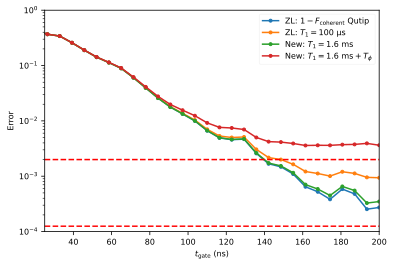

In [18]:
fig, ax = plt.subplots(figsize=(6,4))
# plt.plot(merged_45_2A_best[:,2], Inf_zl_100, 'x', label=r'ZL: $1-F_{\rm coherent}$')
plt.plot(merged_45_2A_best[:,2], Inf_ideal_100, '.-', label=r'ZL: $1-F_{\rm coherent}\ {\rm Qutip}$')
plt.plot(merged_45_2A_best[:,2], Inf_noise_100, '.-', label=r'ZL: $T_1={\rm 100\ \mu s}$')
# plt.plot(merged_45_2A_best[:,2], Inf_noise_1600, '.-', label=r'ZL: ${\rm 1.6\ ms}$')
# plt.plot(merged_45_2A_best[:,2], Inf_noise_t1tphi, '.-', label=r'ZL: $T_1=1.6\ {\rm ms}+T_{\phi}$')
plt.plot(merged_45_2A_best[:,2], Inf_new_1600, '.-', label=r'New: $T_1=1.6\ {\rm ms}$')
plt.plot(merged_45_2A_best[:,2], Inf_new_1600_tphi_2, '.-', label=r'New: $T_1=1.6\ {\rm ms}+T_{\phi}$')
plt.axhline(y=200/100e3, color='r', linestyle='--')
plt.axhline(y=200/1600e3, color='r', linestyle='--')
plt.yscale('log')
plt.xlabel(r'$t_{\rm gate}$ (ns)')
plt.ylabel('Error')
# plt.grid()
plt.xlim(25,200)
plt.ylim(0.0001,1)
legend = plt.legend(loc='best')
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

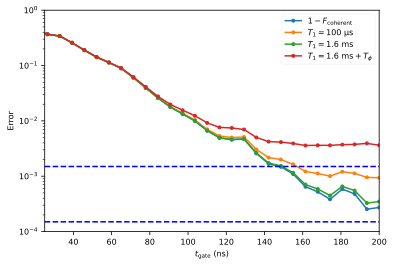

In [19]:
fig, ax = plt.subplots(figsize=(6,4))
plt.plot(merged_45_2A_best[:,2], Inf_ideal_100, '.-', label=r'$1-F_{\rm coherent}$')
plt.plot(merged_45_2A_best[:,2], Inf_noise_100, '.-', label=r'$T_1={\rm 100\ \mu s}$')
plt.plot(merged_45_2A_best[:,2], Inf_new_1600, '.-', label=r'$T_1=1.6\ {\rm ms}$')
plt.plot(merged_45_2A_best[:,2], Inf_new_1600_tphi_2, '.-', label=r'$T_1=1.6\ {\rm ms}+T_{\phi}$')
tg = 200
g = 0.75
plt.axhline(y= g*tg/1000e3, color='b', linestyle='--')
plt.axhline(y= g*tg/100e3, color='b', linestyle='--')
plt.yscale('log')
plt.xlabel(r'$t_{\rm gate}$ (ns)')
plt.ylabel('Error')
# plt.grid()
plt.xlim(25,200)
plt.ylim(0.0001,1)
legend = plt.legend(loc='best')
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

In [20]:
tg_vec = np.linspace(20, 200, num=15)
tg_bounds = []
for i in range(len(tg_vec)):
    tg_bounds.append((tg_vec[i]-0.00001, tg_vec[i]))
print(tg_bounds)
print('\n', tg_vec)

[(19.99999, 20.0), (32.85713285714286, 32.85714285714286), (45.71427571428571, 45.714285714285715), (58.571418571428566, 58.57142857142857), (71.42856142857143, 71.42857142857143), (84.28570428571429, 84.28571428571429), (97.14284714285714, 97.14285714285714), (109.99999, 110.0), (122.85713285714286, 122.85714285714286), (135.71427571428572, 135.71428571428572), (148.57141857142858, 148.57142857142858), (161.42856142857144, 161.42857142857144), (174.28570428571427, 174.28571428571428), (187.14284714285714, 187.14285714285714), (199.99999, 200.0)]

 [ 20.          32.85714286  45.71428571  58.57142857  71.42857143
  84.28571429  97.14285714 110.         122.85714286 135.71428571
 148.57142857 161.42857143 174.28571429 187.14285714 200.        ]


In [21]:
params = np.array([
    [ 2.93782707e-01,  2.07163345e-01,  2.00000000e+01,   -2.99853463e-01, -2.81048967e-01, -3.27570812e-01],
    [ 1.99867633e-01,  1.65429125e-01,  2.64300000e+01,        -2.99951100e-01, -2.85620118e-01, -3.85077565e-01],
    [ 1.02410895e-01,  6.65714640e-02,  3.28571429e+01,        -2.46259456e-01, -2.42666790e-01, -4.06779848e-01],
    [ 9.84521169e-02,  6.35170012e-02,  3.92871429e+01,        -2.45635387e-01, -2.42616658e-01, -5.25405502e-01],
    [ 9.28765245e-02,  6.18442825e-02,  4.57142857e+01,        -2.45198180e-01, -2.42282881e-01, -6.55342504e-01],

    [ 8.50073482e-02,  5.85607676e-02,  5.21442857e+01,        -2.41482954e-01, -2.38807023e-01, -7.74712283e-01],
    [ 8.19633839e-02,  5.83129845e-02,  5.85714286e+01,        -2.42999483e-01, -2.39996871e-01, -8.68408959e-01],
    [ 9.08543300e-02,  6.72393900e-02,  6.50014284e+01,        -2.61689430e-01, -2.57728800e-01, -9.84421406e-01],
    [ 8.77105890e-02,  6.68604305e-02,  7.14285714e+01,        -2.62456488e-01, -2.58722899e-01, -1.15048185e+00],
    [ 8.26896087e-02,  6.48637726e-02,  7.78585714e+01,        -2.59804829e-01, -2.55845581e-01, -1.32948344e+00],

    [ 8.01041189e-02,  6.29575207e-02,  8.42857143e+01,        -2.57971464e-01, -2.54357292e-01, -1.51032781e+00],
    [ 7.71941252e-02,  6.14696625e-02,  9.07157143e+01,        -2.56441326e-01, -2.52954399e-01, -1.66800102e+00],
    [0.075351643, 0.06135683, 97.14285, -0.25725, -0.25353, -1.79079],

    [ 7.60520623e-02,  6.39432799e-02,  1.03572857e+02,        -2.63253918e-01, -2.59046309e-01, -1.93110218e+00],
    [ 7.45778117e-02,  6.34654436e-02,  1.10000000e+02,        -2.63462937e-01, -2.59269155e-01, -2.11694638e+00],

    [ 7.30722502e-02,  6.20440074e-02,  1.16430000e+02,        -2.62115084e-01, -2.58149714e-01, -2.25041164e+00],
    [ 7.16774353e-02,  6.10992882e-02,  1.22857143e+02,        -2.61474000e-01, -2.57563815e-01, -2.28375390e+00],
    [ 1.39375677e-01,  4.12452337e-02,  1.29287143e+02,        -2.60842903e-01, -2.79434355e-01, -2.26002033e+00],
    [ 1.36380478e-01,  3.94416719e-02,  1.35714286e+02,        -2.59402399e-01, -2.76635053e-01, -2.50436000e+00],
    [ 1.33690914e-01,  3.79693451e-02,  1.42140000e+02,        -2.58306995e-01, -2.74236850e-01, -2.68068000e+00],

    [ 1.33143163e-01,  3.69228390e-02,  1.48571428e+02,        -2.58921599e-01, -2.74046847e-01, -2.73726000e+00],
    [ 1.40342948e-01,  3.71991110e-02,  1.55001429e+02,        -2.66083127e-01, -2.81628325e-01, -2.88338727e+00],
    [ 1.39949303e-01,  3.61571071e-02,  1.61428573e+02,        -2.66656925e-01, -2.81472098e-01, -3.11159000e+00],
    [ 1.39496859e-01,  3.55201590e-02,  1.67858570e+02,        -2.67606025e-01, -2.81677946e-01, -3.21012000e+00],
    [ 1.36599461e-01,  3.43961750e-02,  1.74285714e+02,        -2.65980086e-01, -2.79133255e-01, -3.32061902e+00],

    [ 1.85754469e-01,  3.80918860e-02,  1.80715714e+02,        -2.95110129e-01, -3.28798105e-01, -3.15373000e+00],
    [ 1.86997685e-01,  3.74284980e-02,  1.87142856e+02,        -2.98005591e-01, -3.30703646e-01, -3.24536000e+00],
    [ 1.32295234e-01,  3.22886233e-02,  1.93572855e+02,        -2.65458734e-01, -2.76565235e-01, -3.51013000e+00],
    [ 2.32894448e-01,  4.20098643e-02,  1.99999999e+02,        -3.33118430e-01, -3.92974542e-01, -3.46532000e+00]
    ])
np.round(params, 3)


array([[ 2.94000e-01,  2.07000e-01,  2.00000e+01, -3.00000e-01,
        -2.81000e-01, -3.28000e-01],
       [ 2.00000e-01,  1.65000e-01,  2.64300e+01, -3.00000e-01,
        -2.86000e-01, -3.85000e-01],
       [ 1.02000e-01,  6.70000e-02,  3.28570e+01, -2.46000e-01,
        -2.43000e-01, -4.07000e-01],
       [ 9.80000e-02,  6.40000e-02,  3.92870e+01, -2.46000e-01,
        -2.43000e-01, -5.25000e-01],
       [ 9.30000e-02,  6.20000e-02,  4.57140e+01, -2.45000e-01,
        -2.42000e-01, -6.55000e-01],
       [ 8.50000e-02,  5.90000e-02,  5.21440e+01, -2.41000e-01,
        -2.39000e-01, -7.75000e-01],
       [ 8.20000e-02,  5.80000e-02,  5.85710e+01, -2.43000e-01,
        -2.40000e-01, -8.68000e-01],
       [ 9.10000e-02,  6.70000e-02,  6.50010e+01, -2.62000e-01,
        -2.58000e-01, -9.84000e-01],
       [ 8.80000e-02,  6.70000e-02,  7.14290e+01, -2.62000e-01,
        -2.59000e-01, -1.15000e+00],
       [ 8.30000e-02,  6.50000e-02,  7.78590e+01, -2.60000e-01,
        -2.56000e-01, -1.32